In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [29]:
BATCH_SIZE = 32
IMAGE_SIZE = 224  
CHANNELS = 3
EPOCHS = 50       

In [30]:


train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage",
    seed=123,
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training"
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage",
    seed=123,
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation"
)

Found 2153 files belonging to 3 classes.
Using 1723 files for training.
Found 2153 files belonging to 3 classes.
Using 430 files for validation.


In [31]:
class_names = train_ds.class_names
print(class_names)

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [32]:
for image_batch, labels_batch in train_ds.take(1):
    print(image_batch.shape)
    print(labels_batch.numpy())

(32, 224, 224, 3)
[1 1 2 0 0 0 0 0 1 1 1 1 0 1 0 1 1 1 0 1 0 2 0 0 2 0 0 1 2 1 0 0]


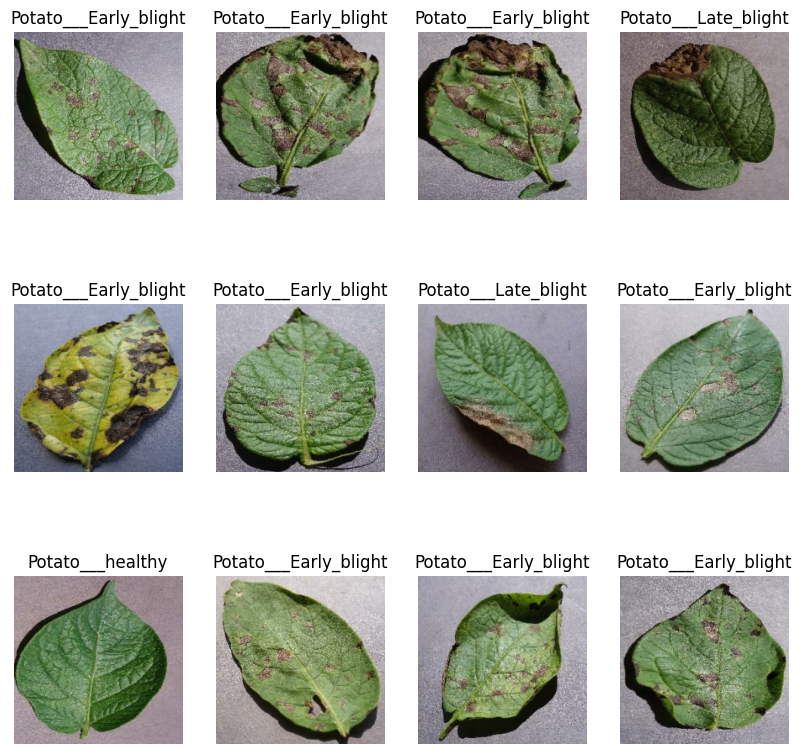

In [33]:
plt.figure(figsize=(10, 10))
for image_batch, labels_batch in train_ds.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")

In [34]:
print("Training batches:", len(train_ds))
print("Validation batches:", len(val_ds))

Training batches: 54
Validation batches: 14


In [35]:
validation_split=0.2
subset="training"
subset="validation"

In [36]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [37]:
resize_and_rescale = tf.keras.Sequential([
    layers.Rescaling(1./255)
])

In [38]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [39]:
model = models.Sequential([
    layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)),

    data_augmentation,
    resize_and_rescale,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(len(class_names), activation='softmax')
])

In [40]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [41]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.7023 - loss: 0.6782 - val_accuracy: 0.7698 - val_loss: 0.5721
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.8746 - loss: 0.3065 - val_accuracy: 0.8837 - val_loss: 0.2753
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.9246 - loss: 0.1962 - val_accuracy: 0.9767 - val_loss: 0.0775
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9530 - loss: 0.1203 - val_accuracy: 0.8744 - val_loss: 0.2889
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9350 - loss: 0.1670 - val_accuracy: 0.9581 - val_loss: 0.1038
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9408 - loss: 0.1534 - val_accuracy: 0.9349 - val_loss: 0.1508
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9652 - loss: 0.1022 - val_accuracy: 0.9558 - val_loss: 0.0899
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9663 - loss: 0.0988 - val_accuracy: 0.9907 - val_loss:

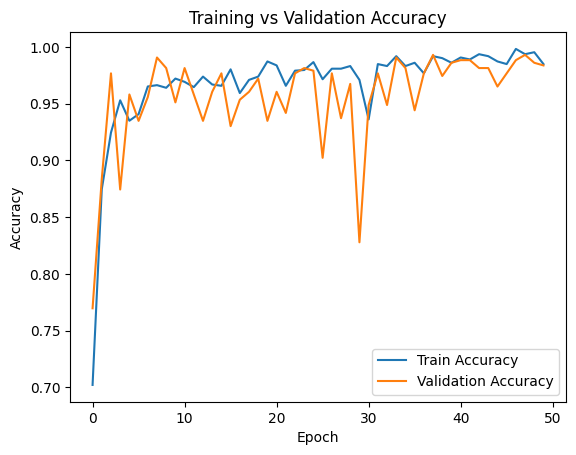

In [43]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

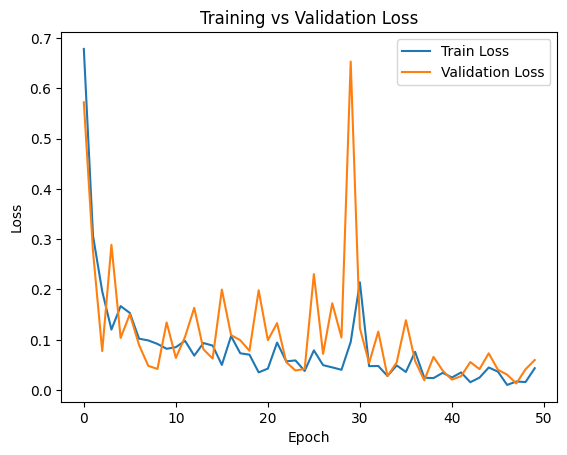

In [44]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [45]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS),
    include_top=False,
    weights="imagenet"
)

In [46]:
base_model.trainable = False

In [47]:
transfer_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dense(len(class_names), activation="softmax")
])

In [48]:
transfer_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [49]:
history_tl = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 46s 747ms/step - accuracy: 0.8143 - loss: 0.4354 - val_accuracy: 0.9116 - val_loss: 0.2340
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 39s 729ms/step - accuracy: 0.9222 - loss: 0.1974 - val_accuracy: 0.9233 - val_loss: 0.1703
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 38s 707ms/step - accuracy: 0.9350 - loss: 0.1736 - val_accuracy: 0.9279 - val_loss: 0.1644
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 38s 702ms/step - accuracy: 0.9565 - loss: 0.1243 - val_accuracy: 0.9442 - val_loss: 0.1394
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 38s 703ms/step - accuracy: 0.9646 - loss: 0.1017 - val_accuracy: 0.9535 - val_loss: 0.1387
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 38s 701ms/step - accuracy: 0.9629 - loss: 0.0969 - val_accuracy: 0.9605 - val_loss: 0.1127
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 38s 711ms/step - accuracy: 0.9762 - loss: 0.0773 - val_accuracy: 0.9674 - val_loss: 0.0996
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 38s 715ms/step - accuracy: 0.9803 - loss: 0.0681 - val_accu

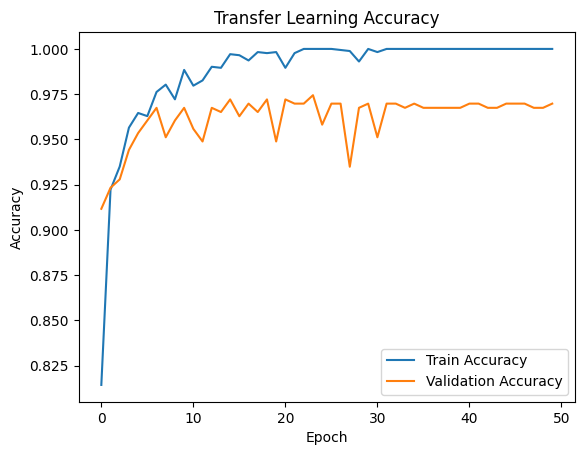

In [50]:
plt.plot(history_tl.history['accuracy'], label='Train Accuracy')
plt.plot(history_tl.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transfer Learning Accuracy")
plt.legend()
plt.show()

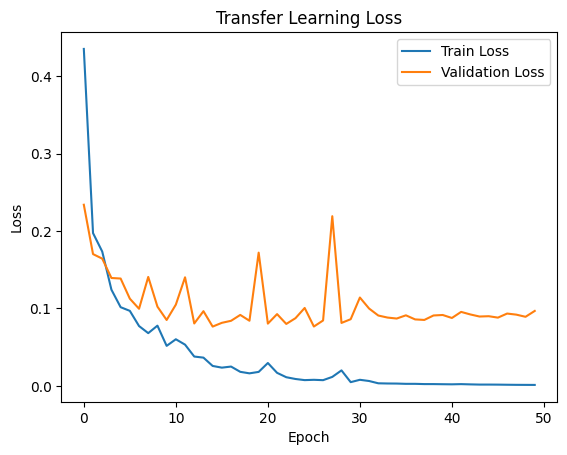

In [51]:
plt.plot(history_tl.history['loss'], label='Train Loss')
plt.plot(history_tl.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transfer Learning Loss")
plt.legend()
plt.show()

In [52]:
cnn_acc = max(history.history['val_accuracy'])
tl_acc = max(history_tl.history['val_accuracy'])

print("CNN Model Best Validation Accuracy:", cnn_acc)
print("Transfer Learning Best Validation Accuracy:", tl_acc)

CNN Model Best Validation Accuracy: 0.9930232763290405
Transfer Learning Best Validation Accuracy: 0.974418580532074


In [53]:
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = transfer_model.predict(images)
    pred_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(pred_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 655ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 604ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 615ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 587ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 627ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 621ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 587ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 607ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 604ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 593ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 583ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 596ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


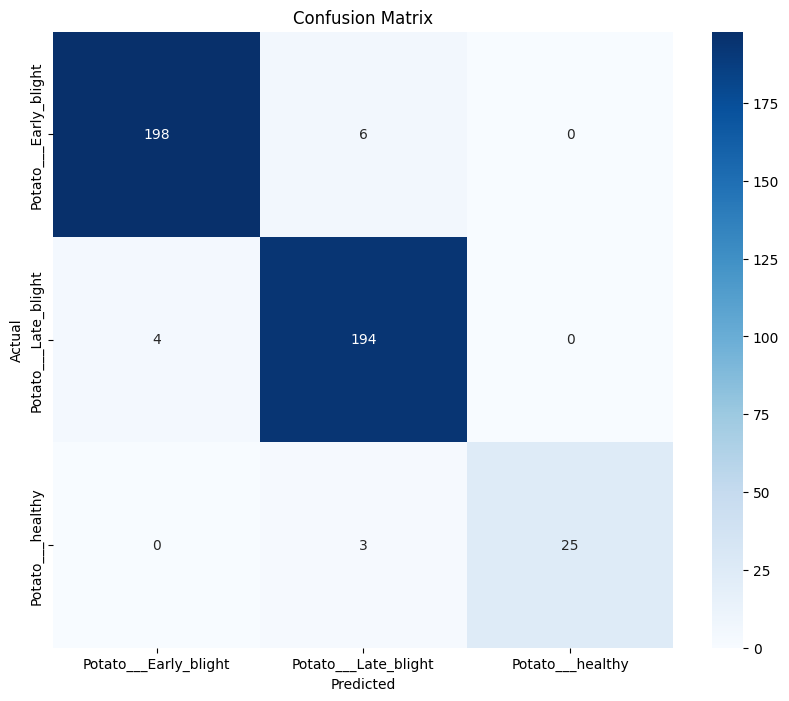

In [54]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [55]:
print(classification_report(y_true, y_pred, target_names=class_names))

                       precision    recall  f1-score   support

Potato___Early_blight       0.98      0.97      0.98       204
 Potato___Late_blight       0.96      0.98      0.97       198
     Potato___healthy       1.00      0.89      0.94        28

             accuracy                           0.97       430
            macro avg       0.98      0.95      0.96       430
         weighted avg       0.97      0.97      0.97       430



In [56]:
IMAGE_SIZE = 224

In [ ]:
print(transfer_model)

In [58]:
img = tf.keras.preprocessing.image.load_img(
    "test_leaf.jpg",
    target_size=(IMAGE_SIZE, IMAGE_SIZE)
)

img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = transfer_model.predict(img_array)
predicted_class = class_names[np.argmax(prediction)]

print("Predicted Disease:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
Predicted Disease: Potato___Early_blight


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Predicted: Potato___Early_blight
Actual: Potato___Early_blight


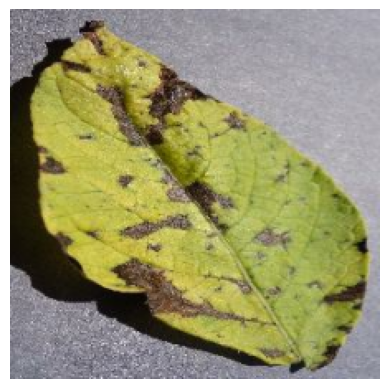

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Predicted: Potato___Late_blight
Actual: Potato___Late_blight


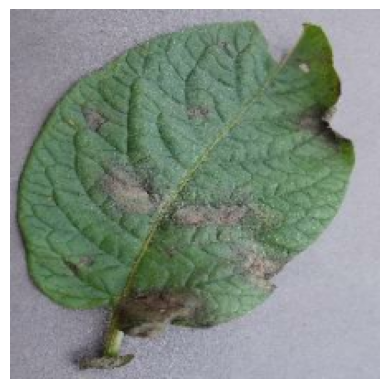

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Predicted: Potato___Late_blight
Actual: Potato___Late_blight


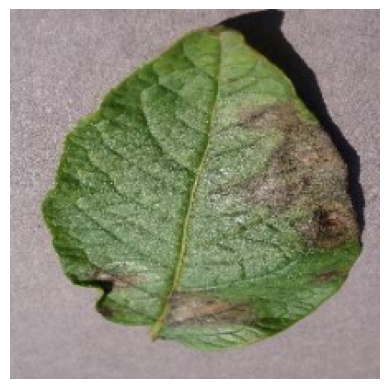

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Predicted: Potato___healthy
Actual: Potato___healthy


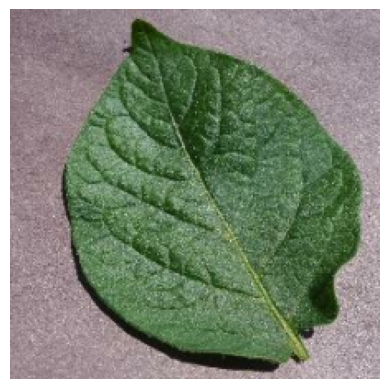

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Predicted: Potato___Early_blight
Actual: Potato___Early_blight


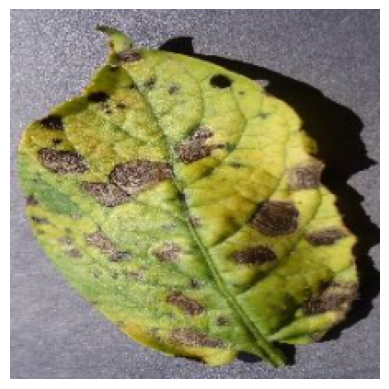

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Predicted: Potato___Late_blight
Actual: Potato___Late_blight


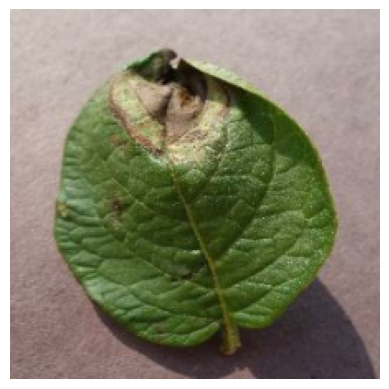

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Predicted: Potato___Late_blight
Actual: Potato___Late_blight


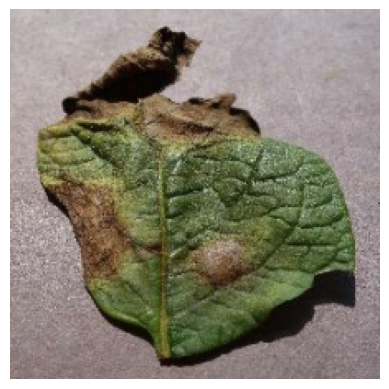

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Predicted: Potato___Early_blight
Actual: Potato___Early_blight


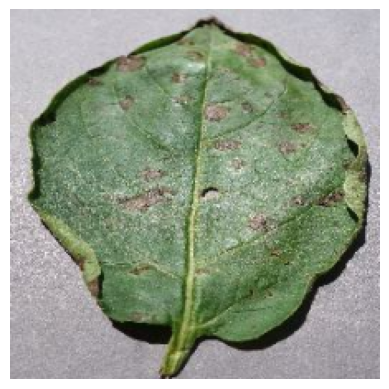

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Predicted: Potato___Late_blight
Actual: Potato___Late_blight


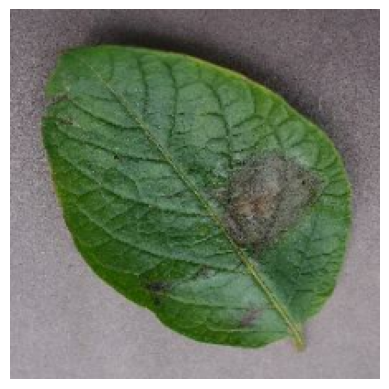

In [59]:
for images, labels in val_ds.take(1):

    for i in range(9):

        img = images[i]

        prediction = transfer_model.predict(np.expand_dims(img, axis=0))

        predicted_class = class_names[np.argmax(prediction)]

        actual_class = class_names[labels[i]]

        print("Predicted:", predicted_class)
        print("Actual:", actual_class)

        plt.imshow(img.numpy().astype("uint8"))
        plt.axis("off")
        plt.show()

In [60]:
print(prediction)

[[4.1849124e-10 9.9999523e-01 4.7278131e-06]]


In [1]:
import os

model_version = max([int(i) for i in os.listdir("../Models")] + [0]) + 1

model.save(f"../Models/{model_version}.keras")

FileNotFoundError: [WinError 3] The system cannot find the path specified: '../Models'

In [2]:
import os

os.makedirs("../Models", exist_ok=True)

In [65]:
transfer_model.save("potato_disease_model.keras")